# Session 4 — Regions, sensitivity, and figures

Attach the position summaries to PTEN's functional regions and test how much the conclusions depend on your filtering choices. Roles rotate at the start of this session.

**Aims** (from the end of the Session 4 slides):
1. Assign each variant a **region** using the supplied annotations.
2. For each region, summarize the number of included variants, the number of included sites, and the total number of sites in the region.
3. For each region, compute and interpret (a) the median of all variant scores in the region and (b) the median across sites of each site's median score.
4. Visualize score statistics by region.
5. Test sensitivity: what happens if you change `minimum_variants` (the number of variants required for a site to be included), or the minimum number of experiments (`expts`) a variant must be measured in?

**Be ready to:** interpret boolean selection for dataframes; compare values across merged dataframes.

**For each analysis, be ready to explain:** what you did, how the code works, and how you checked it.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Functions
All the functions used in this notebook are defined here, once. `get_checked_missense` and `site_stats` are the same as in Session 3 (their contracts and tests are in that notebook). `make_site_region` and `region_summary` are new.

In [2]:
# 3-letter amino acid code -> 1-letter code
letter = {"Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C", "Gln": "Q", "Glu": "E", "Gly": "G",
          "His": "H", "Ile": "I", "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P", "Ser": "S",
          "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V"}


def read_fasta(path):
    """Return the protein sequence in a FASTA file as one string."""
    lines = path.read_text().splitlines()
    return "".join(line.strip() for line in lines if not line.startswith(">"))


def get_checked_missense(table, ref_seq):
    """Return the missense rows of table, with new columns wt, pos, and mut.

    Raises ValueError if a label cannot be parsed, is not a real substitution,
    sits outside the protein, has a WT residue that does not match ref_seq, or
    is duplicated. Missing scores are kept as NaN.
    """
    df = table[table["record_type"] == "missense"].copy()

    # "p.His75Asp" -> wt "His", site 75, mutant "Asp"
    parts = df["hgvs_pro"].str.extract(r"^p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$")
    if parts[0].isna().any():
        raise ValueError("unparseable label(s): " + str(df.loc[parts[0].isna(), "hgvs_pro"].tolist()[:5]))
    df["wt"], df["pos"], df["mut"] = parts[0], parts[1].astype(int), parts[2]

    if not df["mut"].isin(list(letter)).all() or (df["mut"] == df["wt"]).any():
        raise ValueError("not a missense substitution")
    if not df["pos"].between(1, len(ref_seq)).all():
        raise ValueError("site outside the protein")

    # sites count from 1, so label the reference letters 1, 2, 3, ...
    ref_by_site = pd.Series(list(ref_seq), index=range(1, len(ref_seq) + 1))
    if (df["wt"].map(letter) != df["pos"].map(ref_by_site)).any():
        raise ValueError("WT residue does not match the reference")
    if df["hgvs_pro"].duplicated().any():
        raise ValueError("duplicate labels")

    df["score"] = pd.to_numeric(df["score"])
    return df[["hgvs_pro", "wt", "pos", "mut", "score", "expts"]]


def site_stats(missense, n_sites, minimum_variants=5):
    """Score statistics for each site 1..n_sites.

    n_variants counts the variants with a score (0 where there are none).
    The statistics are NaN, never 0, where n_variants < minimum_variants.
    """
    scored = missense.dropna(subset=["score"])
    stats = scored.groupby("pos")["score"].agg(["count", "mean", "median", "std", "min", "max"])
    stats = stats.reindex(range(1, n_sites + 1))
    stats["count"] = stats["count"].fillna(0).astype(int)
    stats.loc[stats["count"] < minimum_variants, ["mean", "median", "std", "min", "max"]] = np.nan
    return stats.rename(columns={"count": "n_variants"})


def make_site_region(regions, n_sites):
    """Region name for each site 1..n_sites; sites in no annotated region are "unannotated"."""
    site_region = pd.Series("unannotated", index=range(1, n_sites + 1))
    for _, r in regions.iterrows():
        site_region.loc[r["start"]:r["end"]] = r["region"]   # .loc includes both ends
    return site_region


def region_summary(missense, site_region, minimum_variants=5, minimum_experiments=1):
    """Summarize each region after filtering variants (expts) and then sites (number of variants).

    Returns (summary, included, site_table):
      summary    one row per region: included_variants, included_sites, total_sites,
                 variant_median (median of all included variants), site_median (median of site medians)
      included   the variants that passed both filters, with a region column
      site_table the included sites, with their statistics and region
    """
    kept = missense[missense["expts"] >= minimum_experiments]
    site_table = site_stats(kept, len(site_region), minimum_variants)
    site_table["region"] = site_region
    site_table = site_table[site_table["n_variants"] >= minimum_variants]

    included = kept[kept["pos"].isin(site_table.index)].copy()
    included["region"] = included["pos"].map(site_region)

    summary = pd.DataFrame({
        "included_variants": included.groupby("region").size(),
        "included_sites": site_table.groupby("region").size(),
        "total_sites": site_region.value_counts(),
        "variant_median": included.groupby("region")["score"].median(),
        "site_median": site_table.groupby("region")["median"].median(),
    }).reindex(list(site_region.unique()))
    summary[["included_variants", "included_sites"]] = summary[["included_variants", "included_sites"]].fillna(0).astype(int)
    return summary, included, site_table

Locate the data. This notebook assumes Jupyter is running with its working directory set to this notebook's folder (`code/my_code`), so the project root is two levels up. If a path check prints `False`, check `Path.cwd()`.

In [3]:
project_root = Path.cwd().parent.parent
data_dir = project_root / "data" / "raw_data"

abundance_path = data_dir / "derived" / "pten-variant-abundance.csv"
regions_path = data_dir / "derived" / "pten-region-annotations.csv"
fasta_path = data_dir / "derived" / "pten-reference-protein.fasta"

abundance_path.exists(), regions_path.exists(), fasta_path.exists()

(True, True, True)

In [4]:
abundance = pd.read_csv(abundance_path)
regions = pd.read_csv(regions_path)
ref_seq = read_fasta(fasta_path)
n_sites = len(ref_seq)

minimum_variants = 5      # a site needs at least this many variants to be included
minimum_experiments = 1   # a variant must be measured in at least this many experiments (every variant has 2 or more, so 1 is no filter)

regions

,region,start,end,source,annotation
0,phosphatase_domain,14,185,UniProt P60484,Phosphatase tensin-type domain
1,c2_domain,190,350,UniProt P60484,C2 tensin-type domain
2,disordered_tail,352,403,UniProt P60484,Disordered region


## Preparing the inputs

The checked missense table from Session 2 and 3, now as one function call.

In [29]:
missense = get_checked_missense(abundance, ref_seq)
print(len(missense))
print(len(missense["pos"].unique()))
missense.head()

4112
360


,hgvs_pro,wt,pos,mut,score,expts
0,p.Met1Val,Met,1,Val,1.065143,4.0
1,p.Thr2Ser,Thr,2,Ser,0.824359,7.0
2,p.Asn12Ile,Asn,12,Ile,0.298717,7.0
3,p.Arg74Val,Arg,74,Val,0.855027,6.0
4,p.His75Ala,His,75,Ala,0.863776,8.0


## Aim 1. Assign each variant a region

Questions to settle first:
- The regions are given as start and end sites. Are both ends included? (Here, yes: `make_site_region` uses `.loc`, which includes both ends.)
- Do the regions cover every site from 1 to 403? What happens to a variant at a site in *no* region? It is labeled `unannotated`, so it is not dropped or relabeled silently.
- Could a site fall into two regions? (If two annotations overlapped, the later row of the region table would overwrite the earlier one, so check the table.)

*Your rule for sites outside all regions:* label them `unannotated` and report them as their own group.

In [25]:
site_region = make_site_region(regions, n_sites)
print(site_region)
missense["region"] = missense["pos"].map(site_region)
missense["region"].value_counts().reindex(list(site_region.unique()))

1          unannotated
2          unannotated
3          unannotated
4          unannotated
5          unannotated
            ...       
399    disordered_tail
400    disordered_tail
401    disordered_tail
402    disordered_tail
403    disordered_tail
Length: 403, dtype: str


region
unannotated            187
phosphatase_domain    1829
c2_domain             1563
disordered_tail        533
Name: count, dtype: int64

**Check:** how many variants land in each region and how many in none? Do the counts add up to your total? Does the number of sites per region match the region table (end - start + 1)?

In [7]:
print("variants in regions add up to total:", missense["region"].value_counts().sum() == len(missense))
print(site_region.value_counts())
print((regions["end"] - regions["start"] + 1).tolist(), "sites per region according to the region table")

variants in regions add up to total: True
phosphatase_domain    172
c2_domain             161
disordered_tail        52
unannotated            18
Name: count, dtype: int64
[172, 161, 52] sites per region according to the region table


**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Aim 2. Region summaries

For each region: included variants, included sites, and total sites in the region. A site is *included* if, after the `minimum_experiments` filter on variants, it still has at least `minimum_variants` variants. The included variants are the variants at included sites. The total number of sites comes from the annotation, whether or not a site was measured.

In [8]:
summary, included, site_table = region_summary(missense, site_region, minimum_variants, minimum_experiments)
summary[["included_variants", "included_sites", "total_sites"]]

,included_variants,included_sites,total_sites
unannotated,179,14,18
phosphatase_domain,1803,142,172
c2_domain,1502,120,161
disordered_tail,521,41,52


**Check:** does included sites <= total sites hold in every region? Do the variant counts match the number of included variants?

In [9]:
print((summary["included_sites"] <= summary["total_sites"]).all())
print(summary["included_variants"].sum() == len(included))

True
True


**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Aim 3. Two medians per region

Compute (a) the median of *all* variant scores in the region, and (b) the median, across included sites, of each site's median score. Questions: why can the two differ? Which sites or variants get more weight in each? What does the difference tell you about the region?

*Your interpretation:*

In [10]:
summary[["variant_median", "site_median"]].round(3)

,variant_median,site_median
unannotated,0.922,0.910
phosphatase_domain,0.719,0.722
c2_domain,0.731,0.752
disordered_tail,0.923,0.942


**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Aim 4. Visualize by region

Questions: what comparison should the figure make obvious? Which plot type fits that: how does it show spread and sample size, not only a single number? How will you show the WT reference?

The left panel shows every included variant score, and the right panel shows one point per included site (its median).

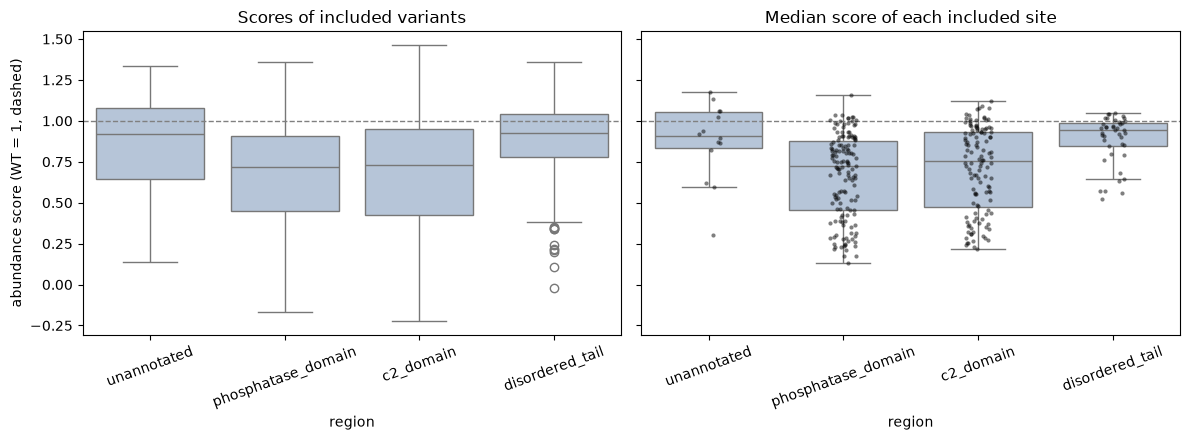

In [11]:
region_order = list(site_region.unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.boxplot(data=included, x="region", y="score", order=region_order, ax=axes[0], color="lightsteelblue")
axes[0].set(title="Scores of included variants", xlabel="region", ylabel="abundance score (WT = 1, dashed)")

sns.boxplot(data=site_table, x="region", y="median", order=region_order, ax=axes[1], color="lightsteelblue",
            showfliers=False)
sns.stripplot(data=site_table, x="region", y="median", order=region_order, ax=axes[1], color="black", size=3, alpha=0.5)
axes[1].set(title="Median score of each included site", xlabel="region", ylabel="")

for ax in axes:
    ax.axhline(1, color="gray", ls="--", lw=1)   # WT reference
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Figure checklist** (from the Session 4 slides)
- Are the labels descriptive and legible, with units where relevant?
- Is the WT reference (score = 1) visible or explained? What is "high" and what is "low"?
- Does `figsize` match the size the figure will be shown at?
- Do color and shape mean the same thing in every panel and figure?
- Is the palette right for the data: distinct colors for unordered groups, sequential for ordered amounts, diverging only around a meaningful center?
- Are colorbars labeled with visible scale marks? Do gridlines stay quiet?

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Aim 5. Sensitivity to filtering choices

`region_summary` takes the filtering settings as inputs, so changing one number reruns the same steps. Below, a **baseline** (`minimum_variants = 5`, no `expts` filter) is compared with alternatives.

*Contract for `region_summary`:* input is the checked missense table, the region of every site, and the two settings. Output is a summary with one row for every region (even a region with no included sites), plus the included variants and included sites. The input table is not changed.

Comparing two results: match rows by an identifier (here, `region`), not by row order. A region present in one result but not the other is *missing*, which is different from a change of zero.

In [12]:
# (minimum_variants, minimum_experiments); the first is the baseline
settings = [(5, 1), (3, 1), (8, 1), (5, 4), (5, 6)]

results = {}
for mv, me in settings:
    label = "sites>=" + str(mv) + ", expts>=" + str(me)
    results[label] = region_summary(missense, site_region, mv, me)[0]

list(results)

['sites>=5, expts>=1',
 'sites>=3, expts>=1',
 'sites>=8, expts>=1',
 'sites>=5, expts>=4',
 'sites>=5, expts>=6']

In [13]:
# Compare each alternative with the baseline, matching on region
baseline_label = list(results)[0]
baseline = results[baseline_label].reset_index(names="region")

for label in list(results)[1:]:
    alternative = results[label].reset_index(names="region")
    matched = baseline.merge(alternative, on="region", how="outer", suffixes=("_baseline", "_alt"),
                             indicator=True, validate="one_to_one")
    matched["site_median_change"] = matched["site_median_alt"] - matched["site_median_baseline"]
    print(label, "versus", baseline_label)
    print(matched[["region", "included_sites_baseline", "included_sites_alt", "site_median_baseline",
                   "site_median_alt", "site_median_change", "_merge"]].round(3).to_string(index=False))
    print()

sites>=3, expts>=1 versus sites>=5, expts>=1
            region  included_sites_baseline  included_sites_alt  site_median_baseline  site_median_alt  site_median_change _merge
         c2_domain                      120                 134                 0.752            0.786               0.034   both
   disordered_tail                       41                  44                 0.942            0.939              -0.003   both
phosphatase_domain                      142                 146                 0.722            0.720              -0.002   both
       unannotated                       14                  16                 0.910            0.929               0.020   both

sites>=8, expts>=1 versus sites>=5, expts>=1
            region  included_sites_baseline  included_sites_alt  site_median_baseline  site_median_alt  site_median_change _merge
         c2_domain                      120                 107                 0.752            0.723              -0.029   both

**Check:** the Session 5 slides report that requiring `expts >= 6` leaves 242 eligible positions and 75 lose eligibility. Does your table agree?

In [14]:
print("sites included, baseline:", results[baseline_label]["included_sites"].sum())
print("sites included, expts>=6:", results["sites>=5, expts>=6"]["included_sites"].sum())

sites included, baseline: 317
sites included, expts>=6: 242


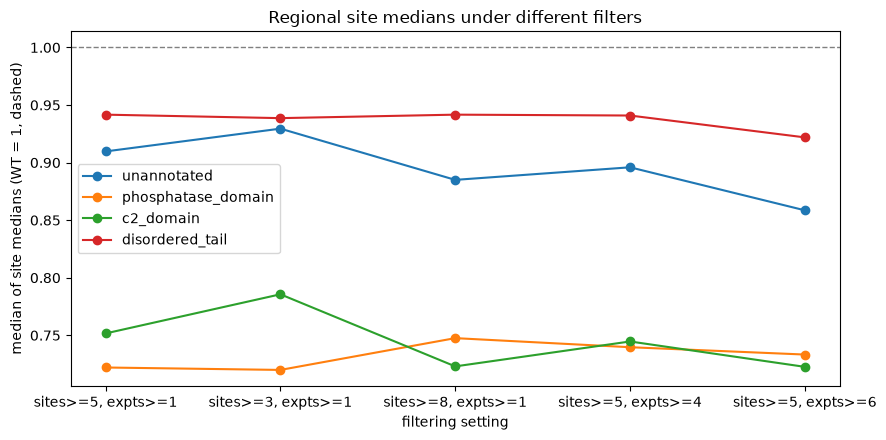

In [15]:
# Site median of each region under every setting
table = pd.DataFrame({label: summary_table["site_median"] for label, summary_table in results.items()}).T

fig, ax = plt.subplots(figsize=(9, 4.5))
for region in region_order:
    ax.plot(table.index, table[region], marker="o", label=region)
ax.axhline(1, color="gray", ls="--", lw=1)   # WT reference
ax.set_xlabel("filtering setting")
ax.set_ylabel("median of site medians (WT = 1, dashed)")
ax.set_title("Regional site medians under different filters")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** which conclusions change and which hold? Is any region's result driven by a few sites? What would make you trust or distrust the regional differences?

*Your interpretation:*

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Reproducibility record

Run this last, after restarting the kernel and running all cells.

In [16]:
import session_info
session_info.show(dependencies=True)